# MIMIC-IV Data Exploration

This notebook performs Exploratory Data Analysis (EDA) on MIMIC-IV data to understand patient statistics, feature distributions, and dataset complexity. The analysis includes patient demographics, admission patterns, laboratory events, microbiology tests, and chart events (vitals).

**Important Note**: The `chartevents` and `labevents` tables are massive. This notebook uses chunking to avoid Out-Of-Memory errors.

## Section 1: Setup & Configuration

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better readability
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Adjust this base path to your MIMIC-IV data directory
#base_path = 'C:\\Users\\Eli\\Data\\physionet.org\\files\\mimiciv\\3.1\\'
base_path = '~/data/physionet.org/files/mimiciv/3.1/'

# Define file paths - update these to match your data location
#patients_file = base_path + 'hosp\\patients.csv.gz'
#admissions_file = base_path + 'hosp\\admissions.csv.gz'
#labevents_file = base_path + 'hosp\\labevents.csv.gz'
#d_labitems_file = base_path + 'hosp\\d_labitems.csv.gz'
#microbiologyevents_file = base_path + 'hosp\\microbiologyevents.csv.gz'
#chartevents_file = base_path + 'icu\\chartevents.csv.gz'
#d_items_file = base_path + 'icu\\d_items.csv.gz'

patients_file = base_path + 'hosp/patients.csv.gz'
admissions_file = base_path + 'hosp/admissions.csv.gz'
labevents_file = base_path + 'hosp/labevents.csv.gz'
d_labitems_file = base_path + 'hosp/d_labitems.csv.gz'
microbiologyevents_file = base_path + 'hosp/microbiologyevents.csv.gz'
omr_file = base_path + 'hosp/omr.csv.gz'
chartevents_file = base_path + 'icu/chartevents.csv.gz'
d_items_file = base_path + 'icu/d_items.csv.gz'


print("File paths defined.")

File paths defined.


## Section 2: Patient & Admission Statistics

Load patient and admission data to understand the overall structure of the dataset.

In [3]:
# Load patients table
print("Loading patients table...")
patients_df = pd.read_csv(patients_file)
print(f"Patients loaded: {len(patients_df)} rows")
print(f"Columns: {list(patients_df.columns)}")

Loading patients table...


Patients loaded: 364627 rows
Columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']


In [4]:
# Load admissions table
print("Loading admissions table...")
admissions_df = pd.read_csv(admissions_file)
print(f"Admissions loaded: {len(admissions_df)} rows")
print(f"Columns: {list(admissions_df.columns)}")

Loading admissions table...


Admissions loaded: 546028 rows
Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


In [5]:
# Calculate basic statistics
total_unique_patients = patients_df['subject_id'].nunique()
total_admissions = len(admissions_df)

print("=" * 80)
print("PATIENT & ADMISSION STATISTICS")
print("=" * 80)
print(f"Total Unique Patients: {total_unique_patients:,}")
print(f"Total Admissions: {total_admissions:,}")
print()

PATIENT & ADMISSION STATISTICS
Total Unique Patients: 364,627
Total Admissions: 546,028



In [6]:
# Calculate admissions per patient
admissions_per_patient = admissions_df.groupby('subject_id').size()

min_admissions = admissions_per_patient.min()
max_admissions = admissions_per_patient.max()
avg_admissions = admissions_per_patient.mean()

print("ADMISSIONS PER PATIENT:")
print(f"  Minimum: {min_admissions}")
print(f"  Maximum: {max_admissions}")
print(f"  Average: {avg_admissions:.2f}")
print("=" * 80)

ADMISSIONS PER PATIENT:
  Minimum: 1
  Maximum: 238
  Average: 2.44


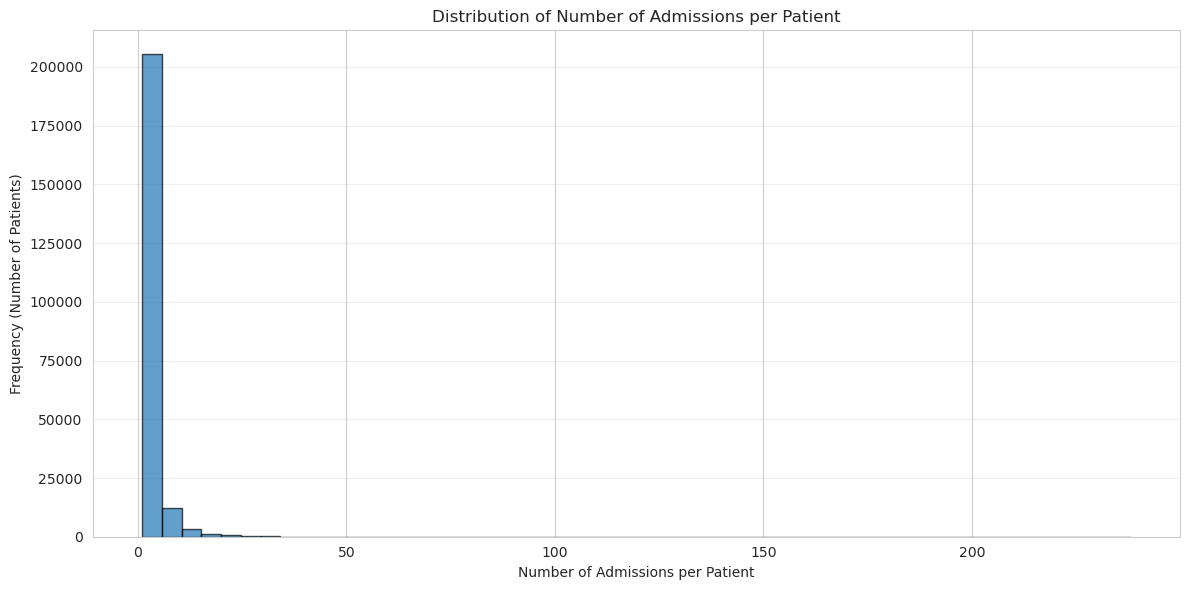

In [7]:
# Visualization: Histogram of admissions per patient
plt.figure(figsize=(12, 6))
plt.hist(admissions_per_patient, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Admissions per Patient')
plt.ylabel('Frequency (Number of Patients)')
plt.title('Distribution of Number of Admissions per Patient')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Section 2.1: Null `dischtime` Analysis

Surviving patients with a null `dischtime` cannot have a valid 30-day readmission
label (Y2) computed. This cell quantifies how many such records exist and how they
are distributed, to inform the pipeline design decision on whether to exclude these
admissions or assign Y2=NaN.

In [8]:
# =============================================================================
# Section 2.1: Null dischtime Analysis
# =============================================================================
# admissions_df is already loaded in Section 2

admissions_df['dischtime'] = pd.to_datetime(admissions_df['dischtime'], errors='coerce')

total_adm   = len(admissions_df)
deceased    = admissions_df['hospital_expire_flag'] == 1
survivors   = admissions_df['hospital_expire_flag'] == 0
null_disch  = admissions_df['dischtime'].isna()

n_deceased  = deceased.sum()
n_survivors = survivors.sum()

surv_null   = survivors & null_disch
n_surv_null = surv_null.sum()

dec_null    = deceased & null_disch
n_dec_null  = dec_null.sum()

print('=' * 80)
print('NULL dischtime ANALYSIS')
print('=' * 80)
print(f'  Total admissions          : {total_adm:>10,}')
print(f'  Deceased  (Y1=1)          : {n_deceased:>10,}  ({n_deceased/total_adm*100:.2f}%)')
print(f'  Surviving (Y1=0)          : {n_survivors:>10,}  ({n_survivors/total_adm*100:.2f}%)')
print()
print(f'  Survivors w/ null dischtime: {n_surv_null:>9,}  ({n_surv_null/n_survivors*100:.3f}% of survivors)')
print(f'  Survivors w/ null dischtime: {n_surv_null:>9,}  ({n_surv_null/total_adm*100:.3f}% of all admissions)')
print()
print(f'  Deceased  w/ null dischtime: {n_dec_null:>9,}  ({n_dec_null/n_deceased*100:.2f}% of deceased)')
print('=' * 80)

if n_surv_null > 0:
    print('\nBy admission_type:')
    print(admissions_df[surv_null]['admission_type'].value_counts().to_string())
    print('\nBy discharge_location:')
    print(admissions_df[surv_null]['discharge_location'].value_counts().head(15).to_string())
    adm_times = pd.to_datetime(admissions_df[surv_null]['admittime'], errors='coerce')
    print(f'\nAdmittime range: {adm_times.min()} — {adm_times.max()}')
else:
    print('\nNo surviving admissions with null dischtime found.')

NULL dischtime ANALYSIS
  Total admissions          :    546,028
  Deceased  (Y1=1)          :     11,801  (2.16%)
  Surviving (Y1=0)          :    534,227  (97.84%)

  Survivors w/ null dischtime:         0  (0.000% of survivors)
  Survivors w/ null dischtime:         0  (0.000% of all admissions)

  Deceased  w/ null dischtime:         0  (0.00% of deceased)

No surviving admissions with null dischtime found.


## Section 3: Mortality Rates

Quantify in-hospital mortality using the admissions table and break it down by admission type. This provides a quick baseline for outcome prevalence before downstream modeling.

In [9]:
print("Calculating in-hospital mortality rates...")
total_admissions = len(admissions_df)
total_deaths = admissions_df["hospital_expire_flag"].sum()
mortality_rate = (total_deaths / total_admissions) * 100

print(f"Total admissions       : {total_admissions:,}")
print(f"Total in-hospital deaths: {total_deaths:,}")
print(f"Overall mortality rate : {mortality_rate:.2f}%")

# Mortality by admission type
mortality_by_type = (
    admissions_df
    .groupby("admission_type")["hospital_expire_flag"]
    .mean()
    .sort_values(ascending=False) * 100
)
print("Mortality rate by admission_type (%):")
print(mortality_by_type.to_string(float_format="{:.2f}".format))

Calculating in-hospital mortality rates...
Total admissions       : 546,028
Total in-hospital deaths: 11,801
Overall mortality rate : 2.16%
Mortality rate by admission_type (%):
admission_type
URGENT                        4.45
EW EMER.                      3.75
DIRECT EMER.                  2.20
OBSERVATION ADMIT             2.18
ELECTIVE                      0.72
SURGICAL SAME DAY ADMISSION   0.35
DIRECT OBSERVATION            0.12
EU OBSERVATION                0.09
AMBULATORY OBSERVATION        0.01


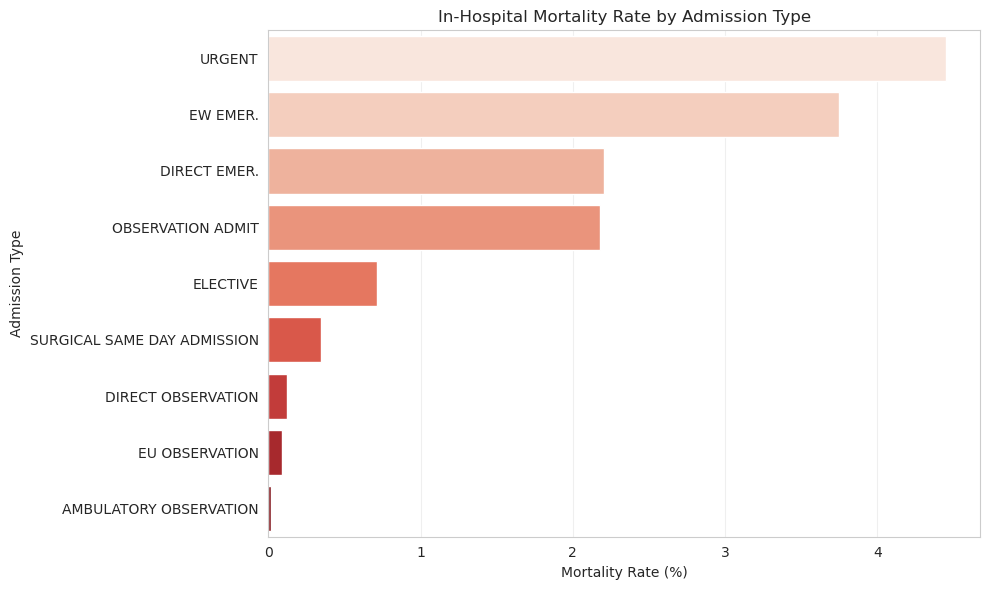

In [10]:
# Visualization: Mortality rate by admission type
plt.figure(figsize=(10, 6))
sns.barplot(
    x=mortality_by_type.values,
    y=mortality_by_type.index,
    hue=mortality_by_type.index,
    palette="Reds",
    legend=False
)
plt.xlabel("Mortality Rate (%)")
plt.ylabel("Admission Type")
plt.title("In-Hospital Mortality Rate by Admission Type")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: 30-Day Readmission Statistics

Compute 30-day readmission labels per admission. An admission is considered a readmission event if the same patient is admitted again within 30 days of discharge. Admissions where the patient died in-hospital are excluded (hospital_expire_flag=1), since those patients cannot be readmitted.

In [11]:
# =============================================================================
# Section 4: 30-Day Readmission Statistics
# =============================================================================
import pandas as pd

# Ensure datetime columns are parsed
adm = admissions_df.copy()
adm['admittime'] = pd.to_datetime(adm['admittime'], errors='coerce')
adm['dischtime'] = pd.to_datetime(adm['dischtime'], errors='coerce')

# Sort by patient and admission time
adm = adm.sort_values(['subject_id', 'admittime']).reset_index(drop=True)

# For each admission, find the next admission time for the same patient
adm['next_admittime'] = adm.groupby('subject_id')['admittime'].shift(-1)

# 30-day readmission label: only for survivors with a valid dischtime
adm['days_to_next_admission'] = (adm['next_admittime'] - adm['dischtime']).dt.total_seconds() / 86400

# Eligible admissions: survived (hospital_expire_flag=0) and has a valid dischtime
eligible = adm[(adm['hospital_expire_flag'] == 0) & adm['dischtime'].notna()].copy()
eligible['readmit_30d'] = (eligible['days_to_next_admission'] >= 0) & (eligible['days_to_next_admission'] <= 30)

total_eligible = len(eligible)
total_readmit  = eligible['readmit_30d'].sum()
readmit_rate   = total_readmit / total_eligible * 100

print('=' * 80)
print('30-DAY READMISSION STATISTICS')
print('=' * 80)
print(f'  Total admissions            : {len(adm):>10,}')
print(f'  In-hospital deaths excluded : {adm["hospital_expire_flag"].sum():>10,}')
print(f'  Eligible admissions (Y2)    : {total_eligible:>10,}')
print()
print(f'  Readmitted within 30 days   : {total_readmit:>10,}  ({readmit_rate:.2f}%)')
print(f'  NOT readmitted within 30 days: {total_eligible - total_readmit:>9,}  ({100 - readmit_rate:.2f}%)')
print('=' * 80)

# Breakdown by admission type
readmit_by_type = (
    eligible.groupby('admission_type')['readmit_30d']
    .agg(total='count', readmitted='sum')
)
readmit_by_type['rate_%'] = readmit_by_type['readmitted'] / readmit_by_type['total'] * 100
readmit_by_type = readmit_by_type.sort_values('rate_%', ascending=False)

print('\n30-Day readmission rate by admission_type:')
print(readmit_by_type.to_string(float_format='{:.2f}'.format))

30-DAY READMISSION STATISTICS
  Total admissions            :    546,028
  In-hospital deaths excluded :     11,801
  Eligible admissions (Y2)    :    534,227

  Readmitted within 30 days   :    109,343  (20.47%)
  NOT readmitted within 30 days:   424,884  (79.53%)

30-Day readmission rate by admission_type:
                              total  readmitted  rate_%
admission_type                                         
DIRECT EMER.                  21489        7096   33.02
ELECTIVE                      13036        3960   30.38
OBSERVATION ADMIT             82598       17844   21.60
EW EMER.                     170809       36384   21.30
DIRECT OBSERVATION            24521        5005   20.41
EU OBSERVATION               119346       23593   19.77
AMBULATORY OBSERVATION         7194        1177   16.36
URGENT                        52484        8053   15.34
SURGICAL SAME DAY ADMISSION   42750        6231   14.58


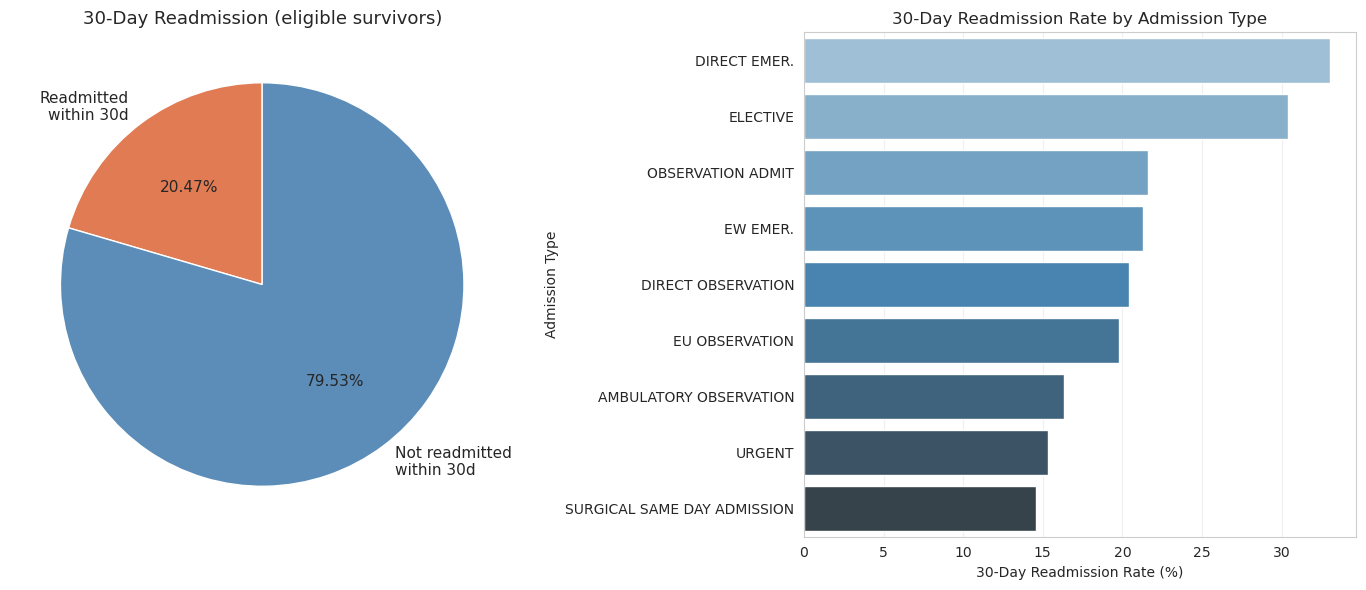

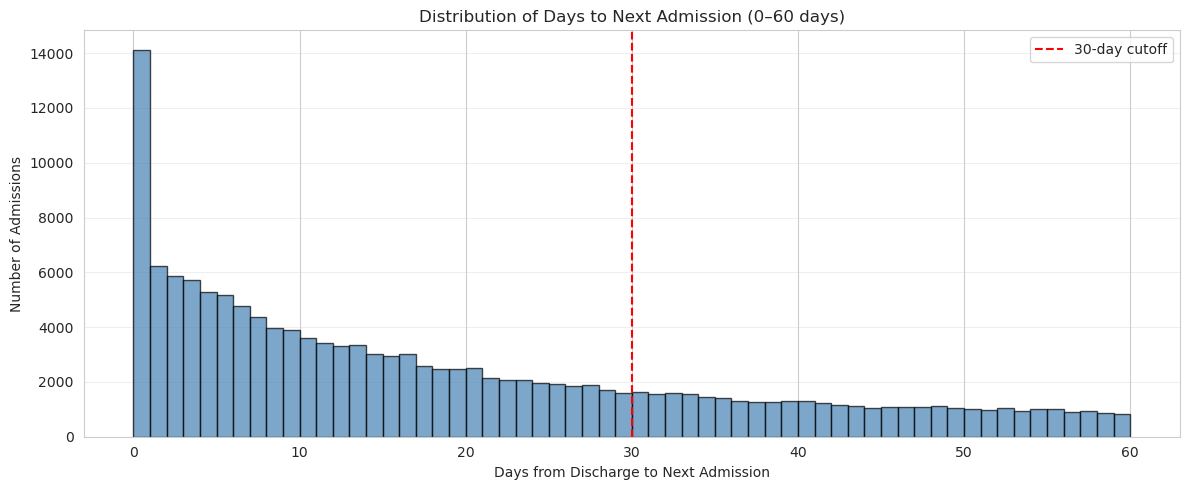

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Overall readmission pie chart ---
labels = ['Readmitted\nwithin 30d', 'Not readmitted\nwithin 30d']
sizes  = [total_readmit, total_eligible - total_readmit]
colors = ['#e07b54', '#5b8db8']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('30-Day Readmission (eligible survivors)', fontsize=13)

# --- Plot 2: Readmission rate by admission type ---
sns.barplot(
    x=readmit_by_type['rate_%'].values,
    y=readmit_by_type.index,
    hue=readmit_by_type.index,
    palette='Blues_d',
    legend=False,
    ax=axes[1]
)
axes[1].set_xlabel('30-Day Readmission Rate (%)')
axes[1].set_ylabel('Admission Type')
axes[1].set_title('30-Day Readmission Rate by Admission Type')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Distribution of days to next admission (within 60d) ---
plt.figure(figsize=(12, 5))
days_vals = eligible.loc[
    eligible['days_to_next_admission'].between(0, 60),
    'days_to_next_admission'
]
plt.hist(days_vals, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='30-day cutoff')
plt.xlabel('Days from Discharge to Next Admission')
plt.ylabel('Number of Admissions')
plt.title('Distribution of Days to Next Admission (0–60 days)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook focuses on high-level patient, admission, and outcome summaries:

1. ✅ **Setup & Configuration**: Imported pandas, matplotlib, seaborn; set readable plot style; defined file paths
2. ✅ **Patient & Admission Statistics**: Calculated total patients, admissions, and admissions per patient; created histogram
3. ✅ **Mortality Rates**: Computed overall in-hospital mortality (2.16%) and breakdown by admission type with visualization
4. ✅ **30-Day Readmission Statistics**: Computed 30-day readmission rate across eligible survivors, breakdown by admission type, and distribution of days-to-next-admission

Laboratory, microbiology, and chart event deep-dives have been moved to dedicated notebooks for focused analysis.

> **Note:** Demographic feature extraction (Age, Gender, Height, Weight, BMI) has been migrated to the dedicated `demographic_feature_exploration.ipynb` notebook.#%%